# Data Preprocessing and EDA Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('cleaned.csv')
df.head()

,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Lanes_or_Medians,Types_of_Junction,Road_surface_type,Light_conditions,Weather_conditions,Type_of_collision,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity
0,18-30,Male,Above high school,Employee,1-2yr,Unknown,No junction,Asphalt roads,Daylight,Normal,Collision with roadside-parked vehicles,Going straight,Not a Pedestrian,Moving Backward,2
1,31-50,Male,Junior high school,Employee,Above 10yr,Undivided Two way,No junction,Asphalt roads,Daylight,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Overtaking,2
2,18-30,Male,Junior high school,Employee,1-2yr,other,No junction,Asphalt roads,Daylight,Normal,Collision with roadside objects,Going straight,Not a Pedestrian,Changing lane to the left,1
3,18-30,Male,Junior high school,Employee,5-10yr,other,Y Shape,Earth roads,Darkness - lights lit,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Changing lane to the right,2
4,18-30,Male,Junior high school,Employee,2-5yr,other,Y Shape,Asphalt roads,Darkness - lights lit,Normal,Vehicle with vehicle collision,Going straight,Not a Pedestrian,Overtaking,2


## 1. Missing Data Checking and Handling

This section loads the dataset and performs initial data exploration to identify missing values and understand the data structure.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age_band_of_driver       12316 non-null  str  
 1   Sex_of_driver            12316 non-null  str  
 2   Educational_level        12316 non-null  str  
 3   Vehicle_driver_relation  12316 non-null  str  
 4   Driving_experience       12316 non-null  str  
 5   Lanes_or_Medians         12316 non-null  str  
 6   Types_of_Junction        12316 non-null  str  
 7   Road_surface_type        12316 non-null  str  
 8   Light_conditions         12316 non-null  str  
 9   Weather_conditions       12316 non-null  str  
 10  Type_of_collision        12316 non-null  str  
 11  Vehicle_movement         12316 non-null  str  
 12  Pedestrian_movement      12316 non-null  str  
 13  Cause_of_accident        12316 non-null  str  
 14  Accident_severity        12316 non-null  int64
dtypes: int64(1), 

In [3]:
df.isnull()

,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Lanes_or_Medians,Types_of_Junction,Road_surface_type,Light_conditions,Weather_conditions,Type_of_collision,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12312,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12313,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
12314,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
print("\nUnique values in key columns:")
print(df['Age_band_of_driver'].unique())


Unique values in key columns:
<StringArray>
['18-30', '31-50', 'Under 18', 'Over 51', 'Unknown']
Length: 5, dtype: str


In [5]:
print(df['Driving_experience'].unique())

<StringArray>
[     '1-2yr', 'Above 10yr',     '5-10yr',      '2-5yr',    'Unknown',
 'No Licence',  'Below 1yr',    'unknown']
Length: 8, dtype: str


In [6]:
print(df['Lanes_or_Medians'].unique())

<StringArray>
[                                         'Unknown',
                                'Undivided Two way',
                                            'other',
                      'Double carriageway (median)',
                                          'One way',
  'Two-way (divided with solid lines road marking)',
 'Two-way (divided with broken lines road marking)']
Length: 7, dtype: str


In [7]:
print(df['Road_surface_type'].unique())

<StringArray>
[                   'Asphalt roads',                      'Earth roads',
                          'Unknown', 'Asphalt roads with some distress',
                     'Gravel roads',                            'Other']
Length: 6, dtype: str


In [8]:
print(df['Accident_severity'].unique())

[2 1 0]


In [9]:
df.duplicated().sum()



np.int64(390)

## 2. Duplicate Data Checking and Handling

Duplicate rows are identified and removed to ensure data integrity. Unique values in key columns are examined to detect any possible entity mismatches.

In [10]:
df = df.drop_duplicates()
df.duplicated().sum()




np.int64(0)

## 3. Encoding Approach for Categorical Features

Categorical features are encoded using appropriate methods. Ordinal features with natural ordering are mapped to numeric values. Nominal features are transformed using one-hot encoding to avoid imposing artificial ordering.

In [11]:
nominal = [
    "Sex_of_driver", "Vehicle_driver_relation", "Lanes_or_Medians",
    "Types_of_Junction", "Road_surface_type", "Light_conditions",
    "Weather_conditions", "Type_of_collision", "Vehicle_movement",
    "Pedestrian_movement", "Cause_of_accident"
]

ordinal = [
    "Age_band_of_driver", "Educational_level",
    "Driving_experience", "Accident_severity"
]

discrete = ["Accident_severity"]
continuous = []

levels_df = pd.DataFrame({
    "Nominal": pd.Series(nominal),
    "Ordinal": pd.Series(ordinal),
    "Discrete": pd.Series(discrete),
    "Continuous": pd.Series(continuous)
})

levels_df


,Nominal,Ordinal,Discrete,Continuous
0,Sex_of_driver,Age_band_of_driver,Accident_severity,NaN
1,Vehicle_driver_relation,Educational_level,NaN,NaN
2,Lanes_or_Medians,Driving_experience,NaN,NaN
3,Types_of_Junction,Accident_severity,NaN,NaN
4,Road_surface_type,NaN,NaN,NaN
5,Light_conditions,NaN,NaN,NaN
6,Weather_conditions,NaN,NaN,NaN
7,Type_of_collision,NaN,NaN,NaN
8,Vehicle_movement,NaN,NaN,NaN
9,Pedestrian_movement,NaN,NaN,NaN


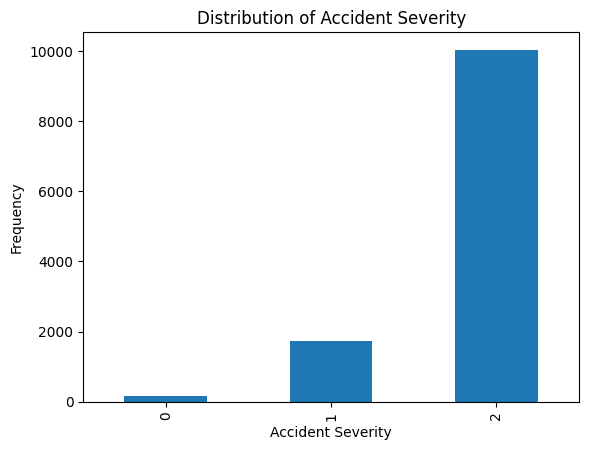

In [12]:
plt.figure()
df["Accident_severity"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Accident Severity")
plt.ylabel("Frequency")
plt.title("Distribution of Accident Severity")
plt.show()


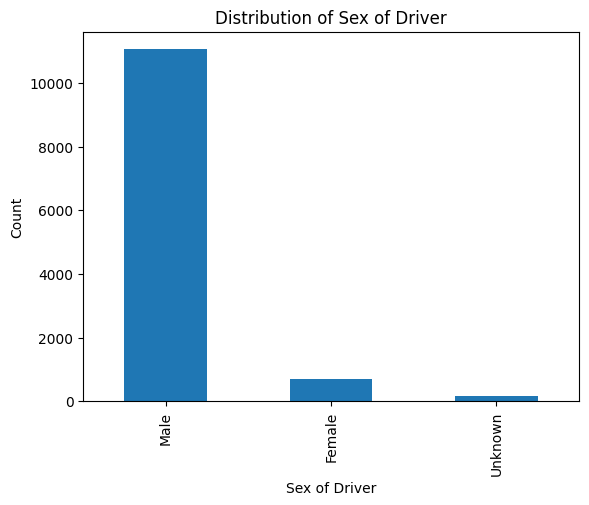

In [13]:
plt.figure()
df['Sex_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Sex of Driver")
plt.ylabel("Count")
plt.title("Distribution of Sex of Driver")
plt.show()


In [14]:
inexperienced = df[df["Driving_experience"].isin(["No Licence", "Below 1yr"])]
experienced = df[df["Driving_experience"].isin(["Above 10yr", "5-10yr"])]
print("Inexperienced Drivers Count:", len(inexperienced))
print("Experienced Drivers Count:", len(experienced))


Inexperienced Drivers Count: 1430
Experienced Drivers Count: 5434


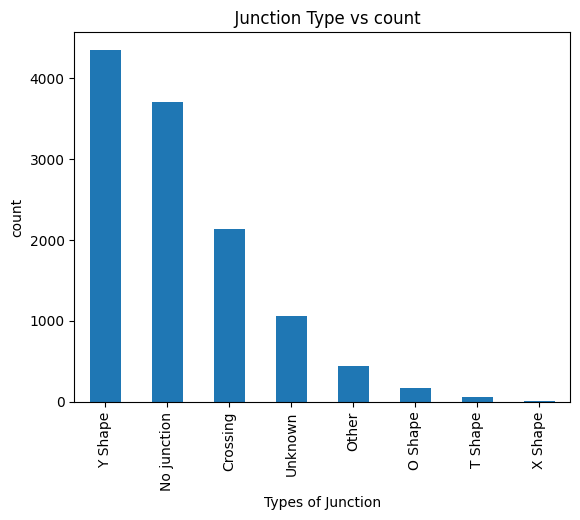

In [15]:
plt.figure()
df['Types_of_Junction'].value_counts().plot(kind='bar')
plt.xlabel("Types of Junction")
plt.ylabel("count")
plt.title("  Junction Type vs count")
plt.show()


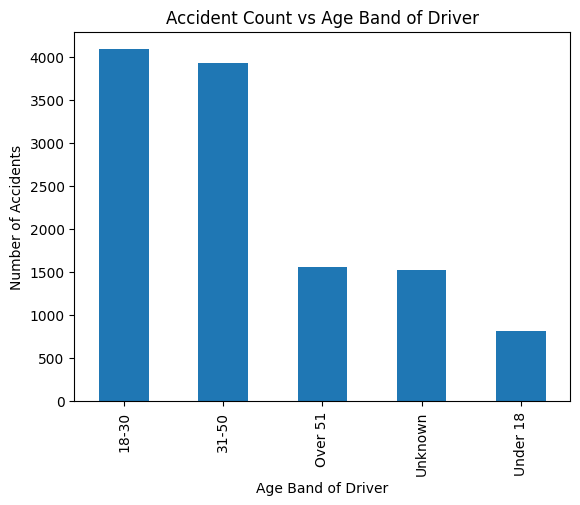

In [16]:
plt.figure()
df['Age_band_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Age Band of Driver")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Age Band of Driver")
plt.show()


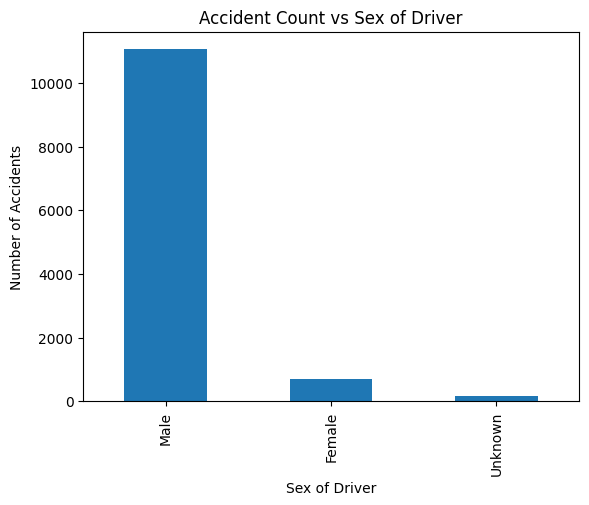

In [17]:
plt.figure()
df['Sex_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Sex of Driver")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Sex of Driver")
plt.show()


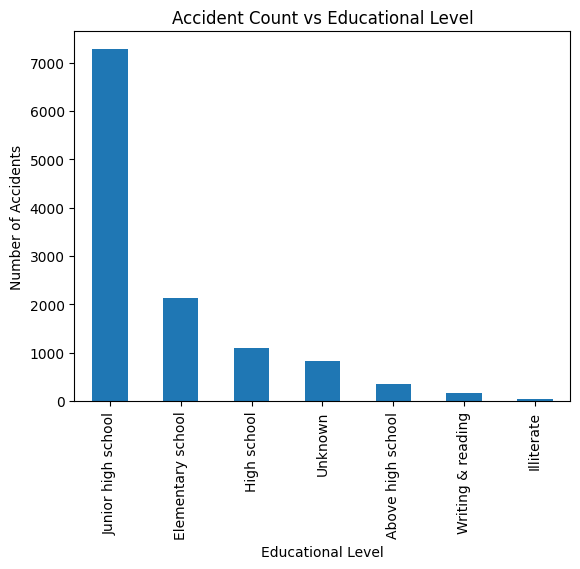

In [18]:
plt.figure()
df['Educational_level'].value_counts().plot(kind='bar')
plt.xlabel("Educational Level")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Educational Level")
plt.show()


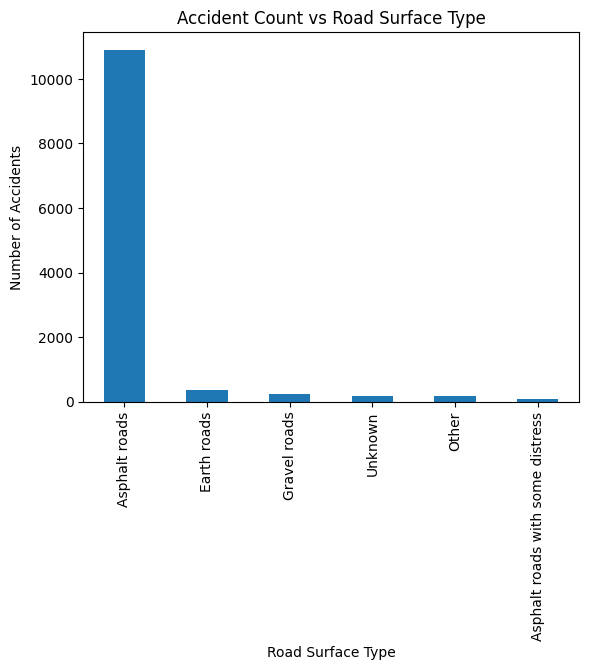

In [19]:
plt.figure()
df['Road_surface_type'].value_counts().plot(kind='bar')
plt.xlabel("Road Surface Type")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Road Surface Type")
plt.show()


In [20]:
df.shape


(11926, 15)

In [21]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col])

## 4. Basic Exploratory Data Analysis

Exploratory Data Analysis includes descriptive statistics and visualizations of both numerical and categorical features. Distribution analysis helps identify patterns and anomalies in the data before modeling.

In [22]:
nominal = [
    "Sex_of_driver", "Vehicle_driver_relation", "Lanes_or_Medians",
    "Types_of_Junction", "Road_surface_type", "Light_conditions",
    "Weather_conditions", "Type_of_collision", "Vehicle_movement",
    "Pedestrian_movement", "Cause_of_accident"
]

ordinal = [
    "Age_band_of_driver", "Educational_level",
    "Driving_experience", "Accident_severity"
]

discrete = ["Accident_severity"]
continuous = []

levels_df = pd.DataFrame({
    "Nominal": pd.Series(nominal),
    "Ordinal": pd.Series(ordinal),
    "Discrete": pd.Series(discrete),
    "Continuous": pd.Series(continuous)
})

levels_df


,Nominal,Ordinal,Discrete,Continuous
0,Sex_of_driver,Age_band_of_driver,Accident_severity,NaN
1,Vehicle_driver_relation,Educational_level,NaN,NaN
2,Lanes_or_Medians,Driving_experience,NaN,NaN
3,Types_of_Junction,Accident_severity,NaN,NaN
4,Road_surface_type,NaN,NaN,NaN
5,Light_conditions,NaN,NaN,NaN
6,Weather_conditions,NaN,NaN,NaN
7,Type_of_collision,NaN,NaN,NaN
8,Vehicle_movement,NaN,NaN,NaN
9,Pedestrian_movement,NaN,NaN,NaN


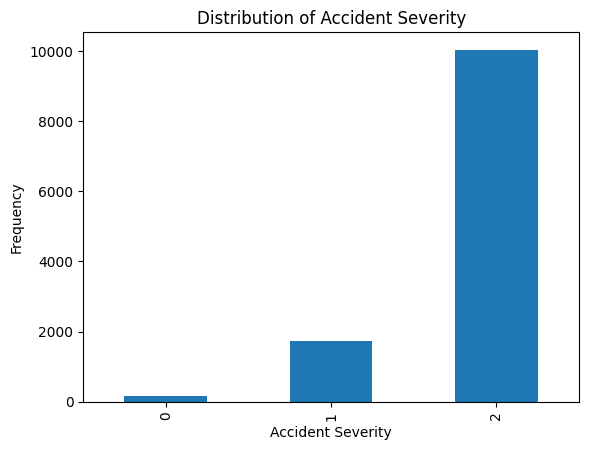

In [23]:
plt.figure()
df["Accident_severity"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Accident Severity")
plt.ylabel("Frequency")
plt.title("Distribution of Accident Severity")
plt.show()


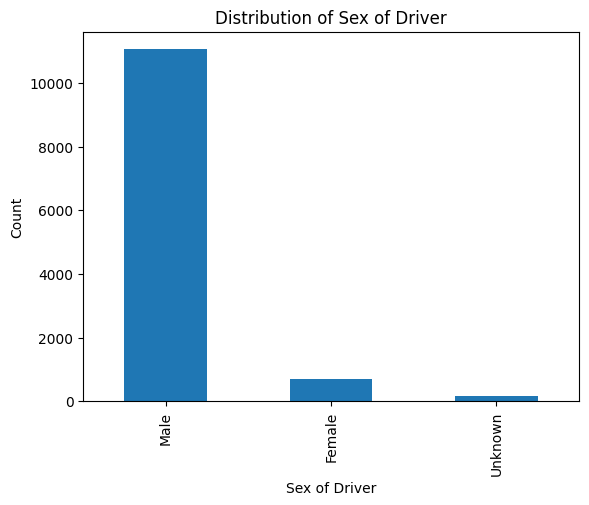

In [24]:
plt.figure()
df['Sex_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Sex of Driver")
plt.ylabel("Count")
plt.title("Distribution of Sex of Driver")
plt.show()


In [25]:
inexperienced = df[df["Driving_experience"].isin(["No Licence", "Below 1yr"])]
experienced = df[df["Driving_experience"].isin(["Above 10yr", "5-10yr"])]
print("Inexperienced Drivers Count:", len(inexperienced))
print("Experienced Drivers Count:", len(experienced))


Inexperienced Drivers Count: 1430
Experienced Drivers Count: 5434


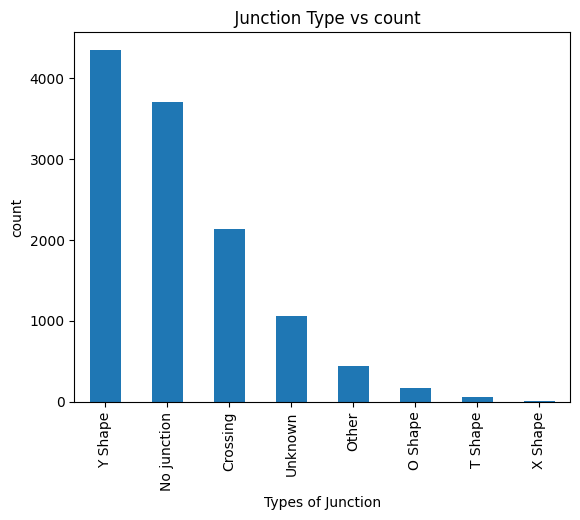

In [26]:
plt.figure()
df['Types_of_Junction'].value_counts().plot(kind='bar')
plt.xlabel("Types of Junction")
plt.ylabel("count")
plt.title("  Junction Type vs count")
plt.show()


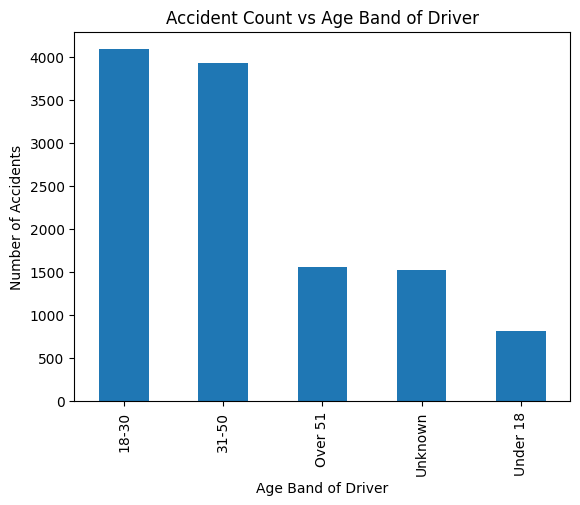

In [27]:
plt.figure()
df['Age_band_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Age Band of Driver")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Age Band of Driver")
plt.show()


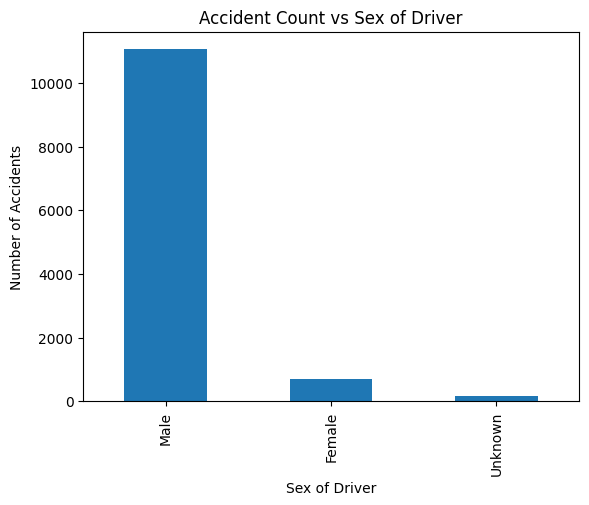

In [28]:
plt.figure()
df['Sex_of_driver'].value_counts().plot(kind='bar')
plt.xlabel("Sex of Driver")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Sex of Driver")
plt.show()


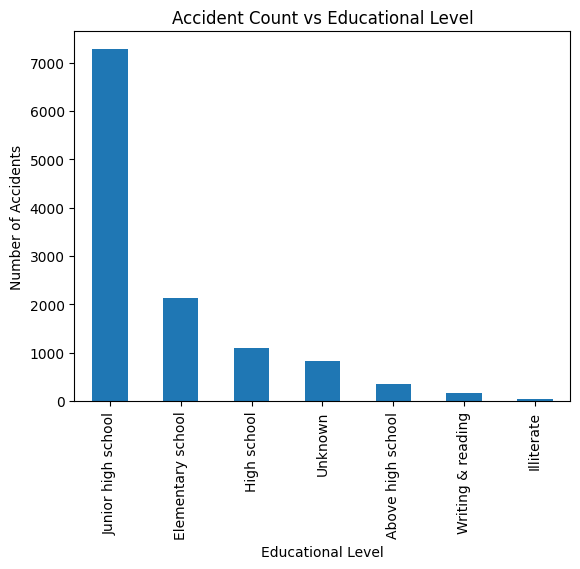

In [29]:
plt.figure()
df['Educational_level'].value_counts().plot(kind='bar')
plt.xlabel("Educational Level")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Educational Level")
plt.show()


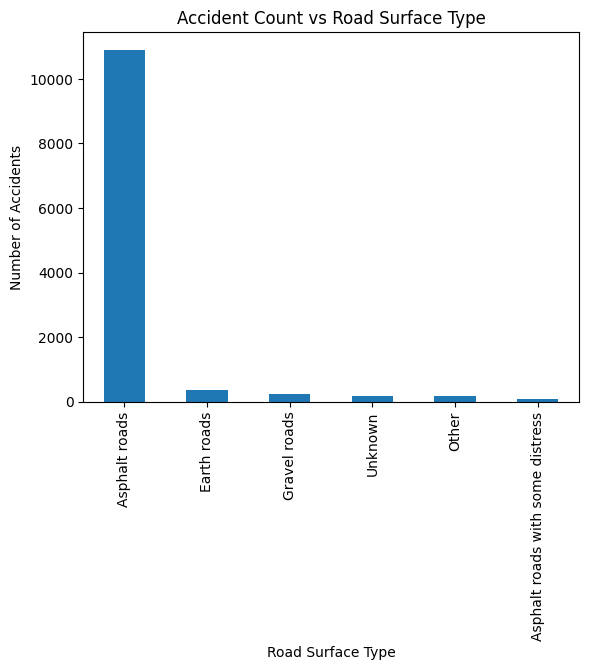

In [30]:
plt.figure()
df['Road_surface_type'].value_counts().plot(kind='bar')
plt.xlabel("Road Surface Type")
plt.ylabel("Number of Accidents")
plt.title("Accident Count vs Road Surface Type")
plt.show()


In [31]:
df.shape


(11926, 15)

In [32]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col])

In [33]:
print(df.shape)
print(df.dtypes)


(11926, 15)
Age_band_of_driver         object
Sex_of_driver              object
Educational_level          object
Vehicle_driver_relation    object
Driving_experience         object
Lanes_or_Medians           object
Types_of_Junction          object
Road_surface_type          object
Light_conditions           object
Weather_conditions         object
Type_of_collision          object
Vehicle_movement           object
Pedestrian_movement        object
Cause_of_accident          object
Accident_severity           int64
dtype: object


In [34]:
print(df.shape)
print(df.dtypes)


(11926, 15)
Age_band_of_driver         object
Sex_of_driver              object
Educational_level          object
Vehicle_driver_relation    object
Driving_experience         object
Lanes_or_Medians           object
Types_of_Junction          object
Road_surface_type          object
Light_conditions           object
Weather_conditions         object
Type_of_collision          object
Vehicle_movement           object
Pedestrian_movement        object
Cause_of_accident          object
Accident_severity           int64
dtype: object


In [ ]:

target_column = "Accident_severity"

print("Target Distribution:")
print(df[target_column].value_counts())


Target Distribution:
Accident_severity
2    10031
1     1737
0      158
Name: count, dtype: int64


In [ ]:

X = df.drop(columns=[target_column])
y = df[target_column]

num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(exclude=np.number).columns

print("Numerical Features:")
print(num_features)

print("\nCategorical Features:")
print(cat_features)


Numerical Features:
Index([], dtype='str')

Categorical Features:
Index(['Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
       'Vehicle_driver_relation', 'Driving_experience', 'Lanes_or_Medians',
       'Types_of_Junction', 'Road_surface_type', 'Light_conditions',
       'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
       'Pedestrian_movement', 'Cause_of_accident'],
      dtype='str')


In [37]:
df.dtypes

Age_band_of_driver         object
Sex_of_driver              object
Educational_level          object
Vehicle_driver_relation    object
Driving_experience         object
Lanes_or_Medians           object
Types_of_Junction          object
Road_surface_type          object
Light_conditions           object
Weather_conditions         object
Type_of_collision          object
Vehicle_movement           object
Pedestrian_movement        object
Cause_of_accident          object
Accident_severity           int64
dtype: object

In [ ]:


ordinal_cols = ['Age_band_of_driver', 'Driving_experience']

continuous_cols = [col for col in num_features if col not in ordinal_cols]

print("Continuous Numerical Features for Outlier Detection:")
print(continuous_cols)


Continuous Numerical Features for Outlier Detection:
[]


In [ ]:


outlier_summary = []

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append([
        col,
        len(outliers),
        round(len(outliers) / len(df) * 100, 2)
    ])

outlier_df = pd.DataFrame(outlier_summary, 
                          columns=["Feature", "Outlier Count", "Outlier %"])

outlier_df


,Feature,Outlier Count,Outlier %


In [40]:
# Apply IQR-based outlier removal
df_no_outliers = df.copy()

for col in continuous_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after outlier removal: {df_no_outliers.shape}")
print(f"Rows removed: {df.shape[0] - df_no_outliers.shape[0]}")

Original dataset shape: (11926, 15)
Dataset shape after outlier removal: (11926, 15)
Rows removed: 0


In [41]:
# Boxplot visualization for outlier detection
if len(continuous_cols) > 0:
    fig, axes = plt.subplots(len(continuous_cols), 1, figsize=(8, 3 * len(continuous_cols)))
    
    if len(continuous_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(continuous_cols):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'Boxplot for {col}')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("No continuous numerical features identified for boxplot visualization.")

No continuous numerical features identified for boxplot visualization.


## 6. Feature Engineering and One-Hot Encoding

Nominal categorical features are transformed using one-hot encoding to create binary columns for each category. This approach avoids imposing artificial ordering on nominal variables.

In [ ]:

import pandas as pd
import numpy as np

df_encoded = df_no_outliers.copy()


age_order = {'Under 18': 0, '18-30': 1, '31-50': 2, 'Over 51': 3}
drive_order = {
    'No Licence': 0, 'Below 1yr': 1, '1-2yr': 2,
    '2-5yr': 3, '5-10yr': 4, 'Above 10yr': 5
}

df_encoded['Age_band_of_driver'] = df_encoded['Age_band_of_driver'].map(age_order)
df_encoded['Driving_experience'] = df_encoded['Driving_experience'].map(drive_order)


for col in ['Age_band_of_driver', 'Driving_experience']:
    median_val = df_encoded[col].median(skipna=True)
    df_encoded[col] = df_encoded[col].fillna(median_val).astype(int)

print('Ordinal encoding complete:')
print(f'  Age dtypes : {df_encoded["Age_band_of_driver"].dtype}, '
      f'unique: {sorted(df_encoded["Age_band_of_driver"].unique())}')
print(f'  Drive dtype: {df_encoded["Driving_experience"].dtype}, '
      f'unique: {sorted(df_encoded["Driving_experience"].unique())}')


nominal_features = [
    'Sex_of_driver', 'Vehicle_driver_relation', 'Lanes_or_Medians',
    'Types_of_Junction', 'Road_surface_type', 'Light_conditions',
    'Weather_conditions', 'Type_of_collision', 'Vehicle_movement',
    'Pedestrian_movement', 'Cause_of_accident', 'Educational_level'
]
df_encoded = pd.get_dummies(df_encoded, columns=nominal_features, drop_first=True)

print(f'\nShape after one-hot encoding: {df_encoded.shape}')
print(f'First few columns: {df_encoded.columns[:6].tolist()}')


Ordinal encoding complete:
  Age dtypes : int64, unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  Drive dtype: int64, unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Shape after one-hot encoding: (11926, 91)
First few columns: ['Age_band_of_driver', 'Driving_experience', 'Accident_severity', 'Sex_of_driver_Male', 'Sex_of_driver_Unknown', 'Vehicle_driver_relation_Other']


## 7. Feature Reduction Using Correlation Analysis

Highly correlated features are identified and removed to reduce multicollinearity and improve model performance. Features with correlation greater than a specified threshold with other input features are eliminated, keeping only the target variable unchanged.

C:\Users\omkha\AppData\Local\Temp\ipykernel_19736\1605137192.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


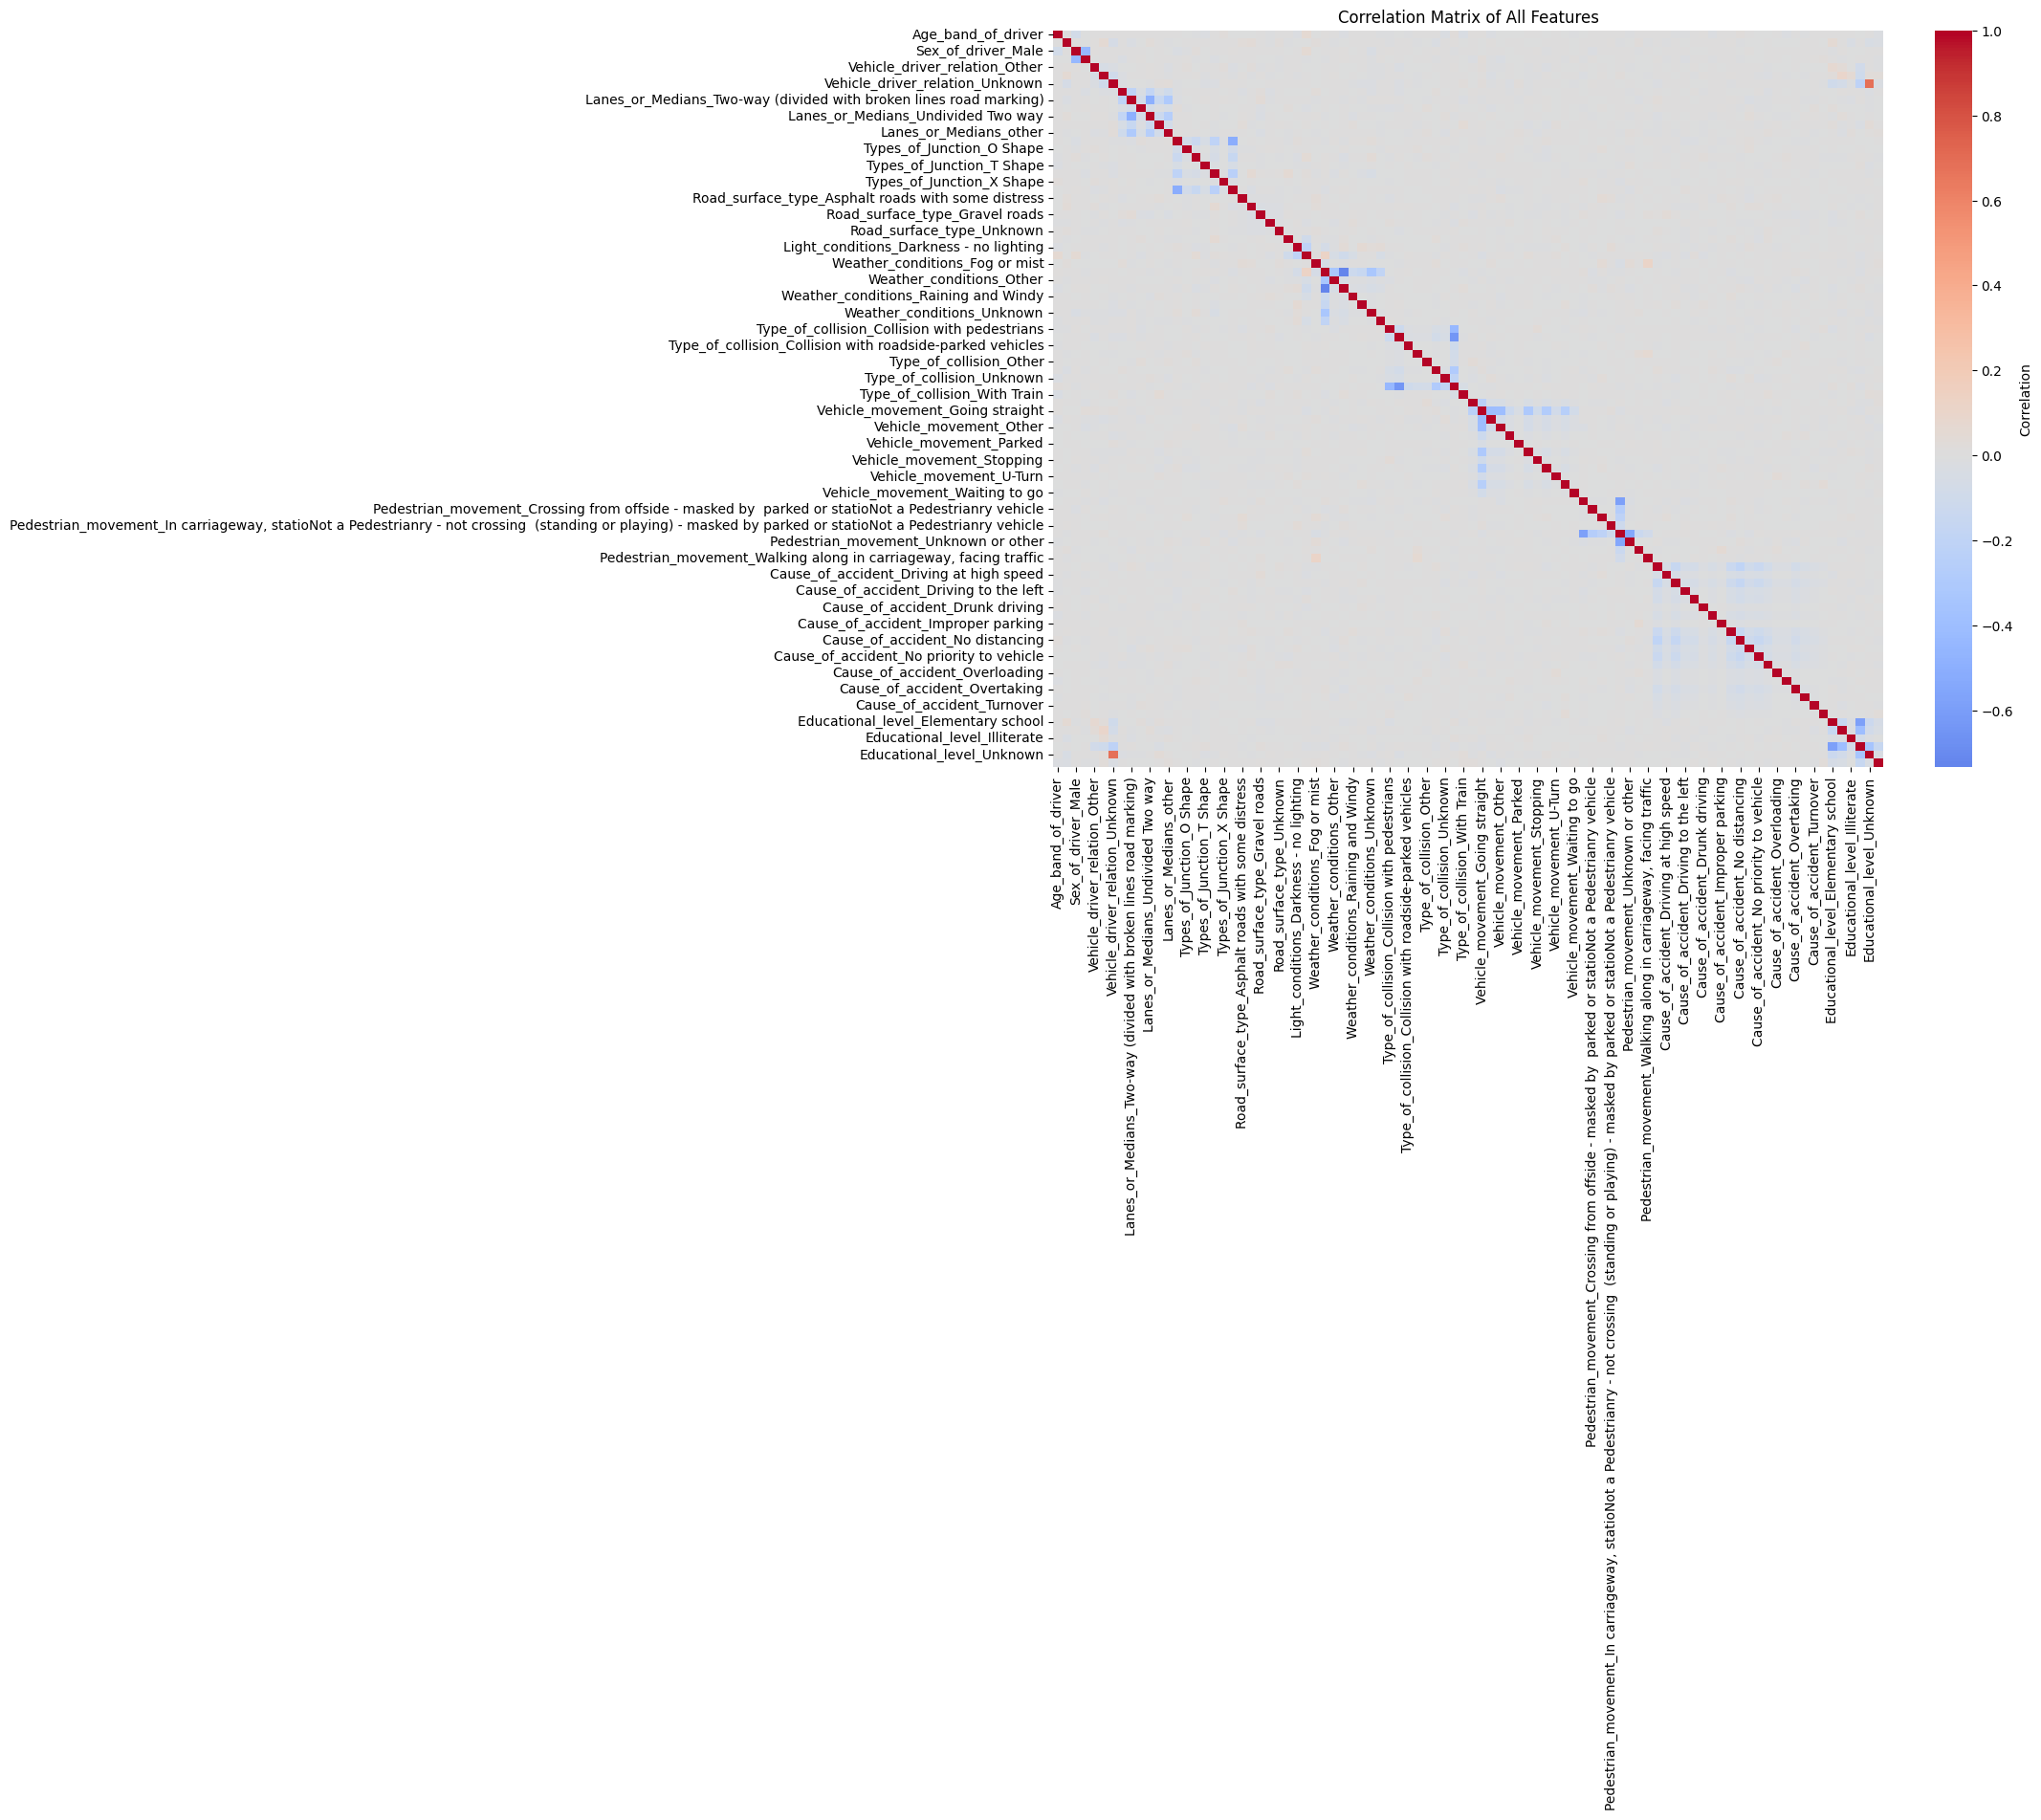

Features dropped (corr > 0.95): 0
Shape before reduction : (11926, 91)
Shape after  reduction : (11926, 91)


In [ ]:

import numpy as np

target_column = 'Accident_severity'

# numeric_only=True required in pandas >= 2.0
correlation_matrix = df_encoded.drop(columns=[target_column]).corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

# Drop features with pairwise correlation > 0.95
threshold = 0.95
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape, dtype=bool), k=1)
)
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

df_reduced = df_encoded.drop(columns=to_drop)
print(f'Features dropped (corr > {threshold}): {len(to_drop)}')
print(f'Shape before reduction : {df_encoded.shape}')
print(f'Shape after  reduction : {df_reduced.shape}')


## 8. Principal Component Analysis (PCA) for Further Feature Reduction

PCA is applied to further reduce the feature space by transforming features into principal components that capture the maximum variance in the data. This technique helps reduce computational complexity while retaining most of the information.

Original number of features: 90
Samples after removing NaN: 11926
Number of PCA components (95% variance): 77
Explained variance ratio: 0.9556


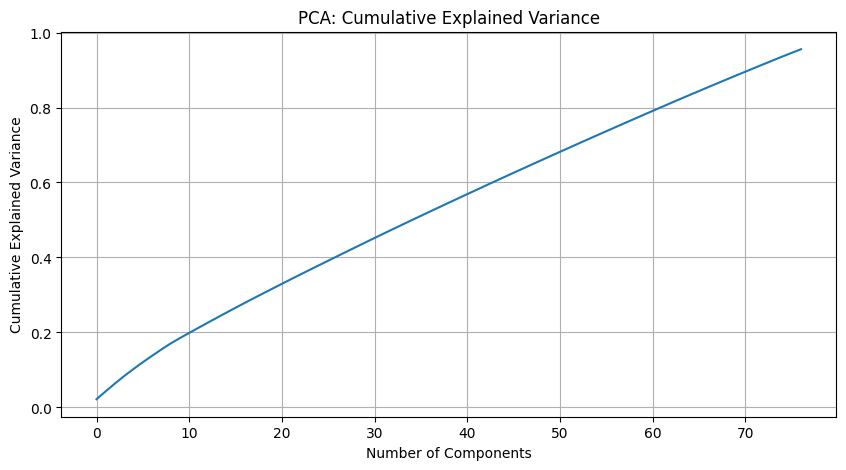


Final dataset shape with PCA: (11926, 78)
PCA dataset ready for model training


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


X_final = df_reduced.drop(columns=['Accident_severity'], errors='ignore')
y_final = df_reduced['Accident_severity'] if 'Accident_severity' in df_reduced.columns else None


X_final_clean = X_final.dropna()
if y_final is not None:
    y_final_clean = y_final.loc[X_final_clean.index]
else:
    y_final_clean = None


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final_clean)


pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_final.shape[1]}")
print(f"Samples after removing NaN: {X_pca.shape[0]}")
print(f"Number of PCA components (95% variance): {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")


plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.grid()
plt.show()


pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
if y_final_clean is not None:
    pca_df['Accident_severity'] = y_final_clean.reset_index(drop=True)

print(f"\nFinal dataset shape with PCA: {pca_df.shape}")
print(f"PCA dataset ready for model training")

## Summary of Data Preprocessing Pipeline

The complete data preprocessing pipeline has been implemented covering the following stages:

1. Missing data identification and basic data exploration
2. Duplicate row detection and removal with unique value verification
3. Ordinal encoding for features with natural ordering (Age, Driving Experience)
4. One-hot encoding for nominal categorical features to avoid artificial ordering
5. Boxplot visualization and IQR-based outlier detection for numerical features
6. Application of IQR method for outlier removal from continuous variables
7. Correlation analysis to identify and remove highly correlated features (threshold: 0.95)
8. Principal Component Analysis to reduce dimensionality while retaining 95% of variance

The processed dataset is now ready for machine learning model training. Two versions are available: the feature-reduced dataset and the PCA-transformed dataset.

---
# Step I – Normality Test BEFORE Scaling

Skewness is measured for all numeric features in the reduced dataset.
Non-binary numeric features with |skewness| > 0.5 receive a `log1p` transformation.
(This is safe because ordinal columns now contain only non-negative integers.)


In [ ]:

import pandas as pd
import numpy as np

target_column = 'Accident_severity'

X = df_reduced.drop(columns=[target_column], errors='ignore').copy()
y = df_reduced[target_column].copy()


bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype(int)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
skewness_before = X[num_cols].skew()

print('Skewness BEFORE scaling (top 10):')
print(skewness_before.sort_values(ascending=False).head(10).to_string())


skewed_features = [
    col for col in num_cols
    if not set(X[col].dropna().unique()).issubset({0, 1})
    and abs(skewness_before[col]) > 0.5
]
print(f'\nSkewed non-binary features: {skewed_features}')

if skewed_features:
    X[skewed_features] = X[skewed_features].apply(np.log1p)
    print('log1p applied.')
else:
    print('No non-binary skewed features – no transformation needed.')

print(f'\nX shape after normality treatment: {X.shape}')


Skewness BEFORE scaling (top 10):
Pedestrian_movement_Walking along in carriageway, facing traffic                                                                                             41.244912
Type_of_collision_With Train                                                                                                                                 36.365430
Weather_conditions_Fog or mist                                                                                                                               34.494929
Vehicle_movement_Parked                                                                                                                                      34.494929
Types_of_Junction_X Shape                                                                                                                                    31.481481
Pedestrian_movement_In carriageway, statioNot a Pedestrianry - not crossing  (standing or playing) - masked by parked or statioNot 

---
# Step J – Scaling / Normalization

**Choice: MinMaxScaler** — scales all values to [0, 1].  
Preferred here because features are mostly binary/ordinal (not Gaussian).  
StandardScaler assumes normal distribution and would distort sparse binary columns.


In [ ]:

from sklearn.preprocessing import MinMaxScaler
import joblib, os

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print('MinMaxScaler applied.')
print(f'Scaled feature matrix shape: {X_scaled_df.shape}')
print('\nFirst 3 rows:')
display(X_scaled_df.head(3))

scaler_path = 'scaler_minmax.joblib'
joblib.dump(scaler, scaler_path)
print(f'\nScaler saved: {os.path.abspath(scaler_path)}')


MinMaxScaler applied.
Scaled feature matrix shape: (11926, 90)

First 3 rows:


,Age_band_of_driver,Driving_experience,Sex_of_driver_Male,Sex_of_driver_Unknown,Vehicle_driver_relation_Other,Vehicle_driver_relation_Owner,Vehicle_driver_relation_Unknown,Lanes_or_Medians_One way,Lanes_or_Medians_Two-way (divided with broken lines road marking),Lanes_or_Medians_Two-way (divided with solid lines road marking),...,Cause_of_accident_Overtaking,Cause_of_accident_Overturning,Cause_of_accident_Turnover,Cause_of_accident_Unknown,Educational_level_Elementary school,Educational_level_High school,Educational_level_Illiterate,Educational_level_Junior high school,Educational_level_Unknown,Educational_level_Writing & reading
0,0.333333,0.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.666667,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.333333,0.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0



Scaler saved: c:\Users\omkha\OneDrive\Desktop\pythoncourse\scaler_minmax.joblib


---
# Step K – Normality Test AFTER Scaling

MinMaxScaler preserves distribution shape, so skewness values remain unchanged.
This confirms the data state before model training.


In [ ]:


skewness_after = X_scaled_df.skew()
comparison = pd.DataFrame({
    'Skewness Before': skewness_before,
    'Skewness After' : skewness_after
})
print('Skewness Before vs After MinMaxScaling (first 10 features):')
display(comparison.head(10))
print('Note: MinMaxScaler preserves distribution shape, so skewness is unchanged.')


Skewness Before vs After MinMaxScaling (first 10 features):


,Skewness Before,Skewness After
Age_band_of_driver,-0.125807,-0.125807
Driving_experience,-0.370915,-0.370915
Sex_of_driver_Male,-3.277594,-3.277594
Sex_of_driver_Unknown,8.001953,8.001953
Vehicle_driver_relation_Other,9.695020,9.695020
Vehicle_driver_relation_Owner,1.813330,1.813330
Vehicle_driver_relation_Unknown,4.184742,4.184742
Lanes_or_Medians_One way,3.378165,3.378165
Lanes_or_Medians_Two-way (divided with broken lines road marking),0.607548,0.607548
Lanes_or_Medians_Two-way (divided with solid lines road marking),9.001019,9.001019


Note: MinMaxScaler preserves distribution shape, so skewness is unchanged.


---
# Step L – Model Training (80/20 Stratified Split)

Four classifiers trained with `class_weight='balanced'` to compensate for class imbalance:
1. Logistic Regression
2. Decision Tree
3. Random Forest (100 trees)
4. Gradient Boosting (100 estimators)


In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'\nClass distribution - train:\n{y_train.value_counts().sort_index()}')
print(f'\nClass distribution - test :\n{y_test.value_counts().sort_index()}')

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

trained_models = {}
for name, clf in models.items():
    print(f'Training {name} ...', end=' ', flush=True)
    clf.fit(X_train, y_train)
    trained_models[name] = clf
    print('Done')

print('\nAll models trained successfully.')


Train size : 9540 | Test size: 2386

Class distribution - train:
Accident_severity
0     126
1    1390
2    8024
Name: count, dtype: int64

Class distribution - test :
Accident_severity
0      32
1     347
2    2007
Name: count, dtype: int64
Training Logistic Regression ... Done
Training Decision Tree ... Done
Training Random Forest ... Done
Training Gradient Boosting ... Done

All models trained successfully.


---
# Step M – Model Evaluation & Saving

Metrics per model: Accuracy, Precision, Recall, F1-Score, ROC-AUC.  
Best model (by weighted F1-Score) saved as `best_model.joblib`.


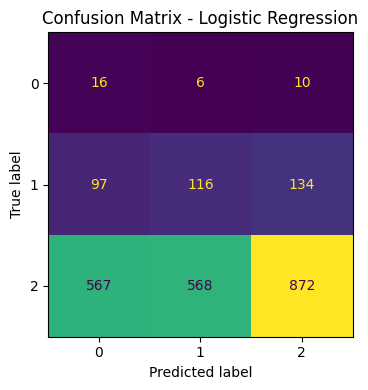


Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.02      0.50      0.04        32
           1       0.17      0.33      0.22       347
           2       0.86      0.43      0.58      2007

    accuracy                           0.42      2386
   macro avg       0.35      0.42      0.28      2386
weighted avg       0.75      0.42      0.52      2386



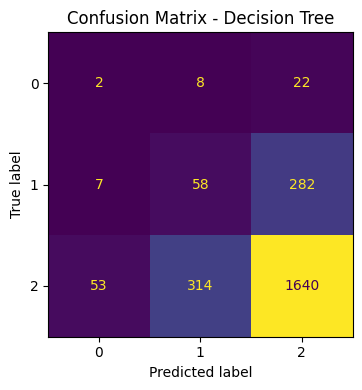


Classification Report: Decision Tree
              precision    recall  f1-score   support

           0       0.03      0.06      0.04        32
           1       0.15      0.17      0.16       347
           2       0.84      0.82      0.83      2007

    accuracy                           0.71      2386
   macro avg       0.34      0.35      0.34      2386
weighted avg       0.73      0.71      0.72      2386



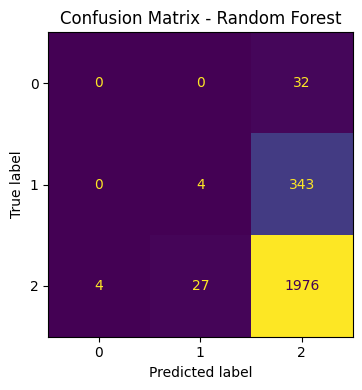


Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.13      0.01      0.02       347
           2       0.84      0.98      0.91      2007

    accuracy                           0.83      2386
   macro avg       0.32      0.33      0.31      2386
weighted avg       0.73      0.83      0.77      2386



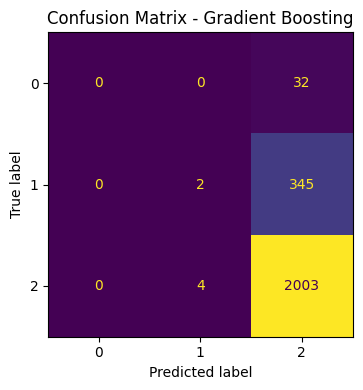


Classification Report: Gradient Boosting
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        32
           1       0.33      0.01      0.01       347
           2       0.84      1.00      0.91      2007

    accuracy                           0.84      2386
   macro avg       0.39      0.33      0.31      2386
weighted avg       0.76      0.84      0.77      2386


MODEL COMPARISON


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.4208,0.7467,0.4208,0.5184,0.5777
Decision Tree,0.7125,0.7322,0.7125,0.7221,0.5108
Random Forest,0.8298,0.7258,0.8298,0.7659,0.4971
Gradient Boosting,0.8403,0.7564,0.8403,0.7698,0.5720



Best model  : Gradient Boosting
Best F1-Score: 0.7698

Best model saved : c:\Users\omkha\OneDrive\Desktop\pythoncourse\best_model.joblib
Scaler saved     : c:\Users\omkha\OneDrive\Desktop\pythoncourse\scaler_minmax.joblib

Full ML pipeline complete.


In [ ]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.preprocessing import label_binarize
import joblib, os

classes = sorted(y.unique())
results = []

for name, clf in trained_models.items():
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test,  y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test,      y_pred, average='weighted', zero_division=0)

    try:
        roc = roc_auc_score(
            label_binarize(y_test, classes=classes),
            y_prob, multi_class='ovr', average='macro'
        )
    except Exception:
        roc = float('nan')

    results.append({
        'Model':     name,
        'Accuracy':  round(acc,  4),
        'Precision': round(prec, 4),
        'Recall':    round(rec,  4),
        'F1-Score':  round(f1,   4),
        'ROC-AUC':   round(roc,  4)
    })

    
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*55}\nClassification Report: {name}\n{'='*55}")
    print(classification_report(y_test, y_pred, zero_division=0))


results_df = pd.DataFrame(results).set_index('Model')
print('\n' + '='*55 + '\nMODEL COMPARISON\n' + '='*55)
display(results_df)

best_name  = results_df['F1-Score'].idxmax()
best_model = trained_models[best_name]
print(f'\nBest model  : {best_name}')
print(f'Best F1-Score: {results_df.loc[best_name, "F1-Score"]}')

model_path = 'best_model.joblib'
joblib.dump(best_model, model_path)
print(f'\nBest model saved : {os.path.abspath(model_path)}')
print(f'Scaler saved     : {os.path.abspath("scaler_minmax.joblib")}')
print('\nFull ML pipeline complete.')
